# Sentiment Analysis of Apple

## 1. Introduction



With the rapid growth of social media and online platforms, large volumes of user-generated textual data are produced daily. Analyzing this data can provide valuable insights into public opinion and customer sentiment.

This project focuses on performing sentiment analysis on text data related to Apple products and services. The goal is to classify user opinions into sentiment categories such as positive, negative, and neutral.

The project follows an end-to-end machine learning pipeline, including data preprocessing, exploratory data analysis (EDA), feature extraction using TF-IDF, and training multiple classification models. The final model is selected based on performance metrics and used to build a prediction system for real-world text inputs.

## 2. Dataset Description

The dataset used in this project was created by combining multiple publicly available sources containing text data related to Apple products and services. These sources include social media platforms, product reviews, and publicly available datasets.

To ensure data quality and consistency, preprocessing steps were applied such as:
- Removal of duplicate entries
- Handling missing values
- Standardizing text formats
- Filtering irrelevant or noisy data

The final dataset was balanced across sentiment classes (positive, negative, and neutral) to avoid bias during model training.

This combined dataset provides a diverse representation of user opinions across different platforms, making it suitable for sentiment analysis tasks.

In [1]:
import pandas as pd
df = pd.read_csv("Balanced_dataset(stopwordremoval).csv")
df.head()

,Sentiment,Text,processed_text
0,0,Google Announces Check-ins: SXSW Location-Base...,googl announc checkin sxsw locationbas geofenc...
1,-1,It was excellent,excel
2,-1,#iPhone battery doesn't last long under #sxsw ...,iphon batteri doesnt last long sxsw usag
3,0,"Google Circles' Looms, But Do Google's Nerds '...",googl circl loom googl nerd get social sxsw li...
4,-1,@apple AirDrop #fail - Immediate declined your...,airdrop fail immedi declin request everi time


In [3]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57072 entries, 0 to 57071
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Sentiment       57072 non-null  int64 
 1   Text            57072 non-null  object
 2   processed_text  57005 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.3+ MB


Sentiment          0
Text               0
processed_text    67
dtype: int64

In [5]:
df['Sentiment'].value_counts()

Sentiment
 0    19024
-1    19024
 1    19024
Name: count, dtype: int64

EDA is performed to understand the distribution of sentiments and identify patterns in the dataset.

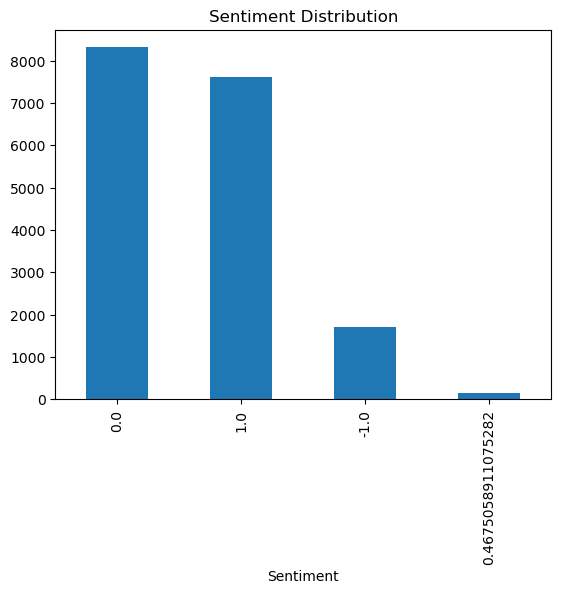

In [46]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

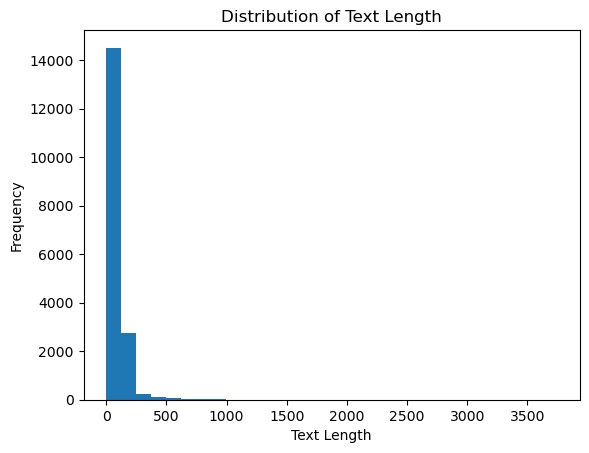

In [49]:
df['text_length'] = df['clean_text'].apply(len)

plt.hist(df['text_length'], bins=30)
plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

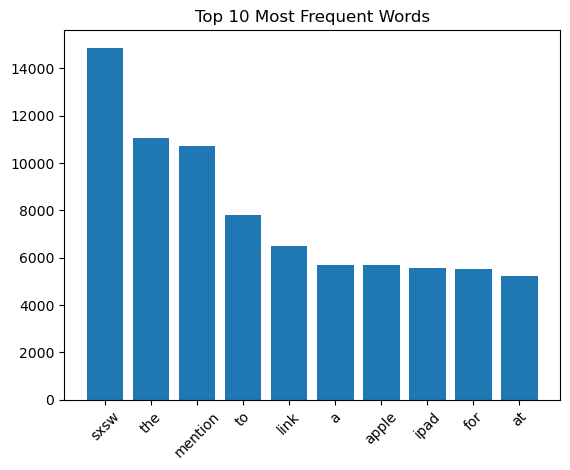

In [51]:
from collections import Counter

all_words = " ".join(df['clean_text'])
words = all_words.split()

word_freq = Counter(words)
common_words = word_freq.most_common(10)

words, counts = zip(*common_words)

plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()


Sentiment analysis is performed to classify text data into positive, negative, or neutral categories. 
In this project, a rule-based approach using TextBlob is used to determine sentiment polarity.

## 3. Data Preprocessing

Text data often contains noise such as special characters, URLs, stopwords, and inconsistent formatting. To improve the quality of the data and make it suitable for machine learning models, several preprocessing steps were applied.

The preprocessing pipeline includes:
- Converting text to lowercase
- Removing URLs and user mentions
- Removing punctuation and numerical values
- Tokenization of text into words
- Removal of stopwords
- Stemming using Porter Stemmer

These steps help in reducing noise, normalizing the text, and improving the effectiveness of feature extraction.

In [16]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download required resources
import nltk

try:
    nltk.data.find('corpora/stopwords')
except:
    nltk.download('stopwords')

try:
    nltk.data.find('tokenizers/punkt')
except:
    nltk.download('punkt')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    tokens = nltk.word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure and characteristics of the dataset.

This includes analyzing text length, word frequency, and identifying commonly used terms. These insights help in understanding patterns in the data before applying machine learning models.

In [18]:
df['processed_text'] = df['processed_text'].fillna("")

df['text_length'] = df['processed_text'].apply(len)

df['text_length'].describe()

count    57072.000000
mean        62.921468
std         99.626194
min          0.000000
25%         17.000000
50%         52.000000
75%         75.000000
max       2107.000000
Name: text_length, dtype: float64

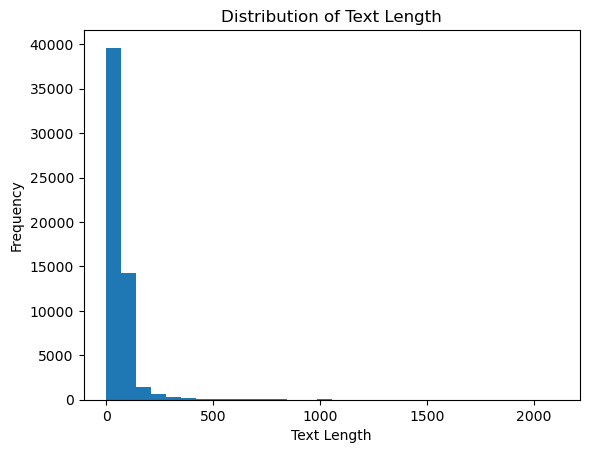

In [20]:
import matplotlib.pyplot as plt

plt.hist(df['text_length'], bins=30)
plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

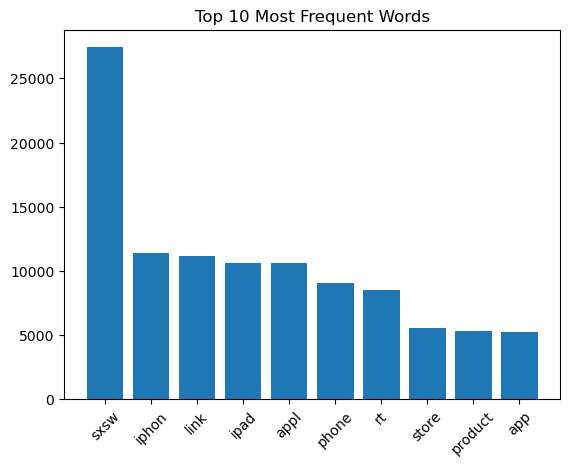

In [22]:
from collections import Counter

all_words = " ".join(df['processed_text'])
words = all_words.split()

word_freq = Counter(words)
common_words = word_freq.most_common(10)

words, counts = zip(*common_words)

plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

In [27]:
!pip install wordcloud

   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   ----- --------------------------------- 41.0/307.2 kB 960.0 kB/s eta 0:00:01
   ------- ------------------------------- 61.4/307.2 kB 812.7 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/307.2 kB 777.7 kB/s eta 0:00:01
   ----------------- -------------------- 143.4/307.2 kB 944.1 kB/s eta 0:00:01
   ------------------------ ------------- 194.6/307.2 kB 980.4 kB/s eta 0:00:01
   ----------------------------- -------- 235.5/307.2 kB 958.6 kB/s eta 0:00:01
   -------------------------------------  307.2/307.2 kB 999.9 kB/s eta 0:00:01
   -------------------------------------- 307.2/307.2 kB 902.7 kB/s eta 0:00:00


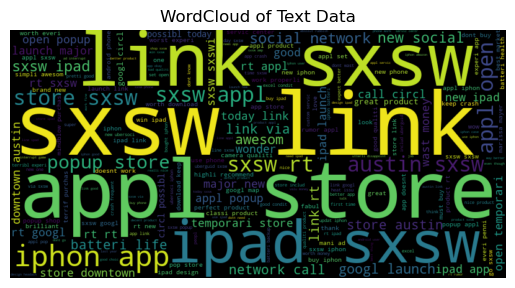

In [29]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate(all_words)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud of Text Data")
plt.show()

### Observations

- The text data varies in length across different entries.
- Frequently occurring words indicate common topics discussed by users.
- The WordCloud highlights dominant terms related to Apple products and user experiences.

## 5. Feature Engineering (TF-IDF)

Machine learning models cannot process raw text directly, so the text data is converted into numerical form using TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF reflects the importance of a word in a document relative to the entire dataset. It helps in giving higher weight to important words while reducing the impact of commonly occurring words.

This transformation allows machine learning algorithms to effectively learn patterns from textual data.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X = tfidf_vectorizer.fit_transform(df['processed_text'])
y = df['Sentiment']

## 6. Train-Test Split

The dataset is split into training and testing sets to evaluate the performance of machine learning models on unseen data. 

80% of the data is used for training and 20% for testing.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 7. Model Building

Multiple machine learning models are trained to classify sentiment. These include:

- Multinomial Naive Bayes
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

Each model is evaluated using performance metrics such as accuracy, precision, recall, and F1-score.

In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": LinearSVC(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }

    print(f"\n{name}")
    for metric, value in results[name].items():
        print(f"{metric}: {value:.4f}")


Naive Bayes
Accuracy: 0.7813
Precision: 0.7937
Recall: 0.7813
F1 Score: 0.7800

Logistic Regression
Accuracy: 0.8081
Precision: 0.8149
Recall: 0.8081
F1 Score: 0.8060

Decision Tree
Accuracy: 0.8492
Precision: 0.8540
Recall: 0.8492
F1 Score: 0.8481

Random Forest
Accuracy: 0.8378
Precision: 0.8418
Recall: 0.8378
F1 Score: 0.8372


C:\Users\yuvas\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(



SVM
Accuracy: 0.8293
Precision: 0.8343
Recall: 0.8293
F1 Score: 0.8275


## 8. Model Selection

The performance of all models is compared, and the best model is selected based on the F1-score, which provides a balance between precision and recall.

The Decision Tree model achieved the highest performance among all models and was selected as the final model.

In [27]:
best_model_name = max(results, key=lambda k: results[k]['F1 Score'])
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Decision Tree


## 9. Final Model Pipeline

A pipeline is created combining TF-IDF vectorization and the selected model. This allows seamless processing of raw text input and prediction.

In [30]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('classifier', best_model)
])

pipeline.fit(df['processed_text'], df['Sentiment'])

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('classifier', DecisionTreeClassifier(random_state=42))])

## 10. Prediction System

A prediction function is created to classify new text inputs into sentiment categories using the trained model.

In [ ]:
import nltk
nltk.download('punkt_tab')

In [37]:
print(predict_sentiment("This product is amazing"))

1


## 11. Results & Insights

Multiple machine learning models were trained and evaluated for sentiment classification. The models were compared based on accuracy, precision, recall, and F1-score.

Among all models, the Decision Tree classifier achieved the best performance with an accuracy of approximately 85% on the test dataset. Other models such as Random Forest and Support Vector Machine also showed competitive performance.

Key observations from the analysis:

- The dataset contains a balanced distribution of positive, negative, and neutral sentiments, which helped in reducing bias during model training.
- TF-IDF proved to be an effective feature extraction technique for textual data.
- Decision Tree performed well in capturing patterns in the dataset, while ensemble models provided stable performance across different metrics.
- The prediction system successfully classifies new text inputs into sentiment categories, demonstrating the practical applicability of the model.

It is also observed that training accuracy is higher when the model is trained on the entire dataset, which may indicate overfitting. Therefore, test accuracy is considered a more reliable measure of performance.

## 12. Conclusion

This project successfully demonstrates an end-to-end sentiment analysis pipeline using machine learning techniques. The workflow includes data collection, preprocessing, exploratory data analysis, feature engineering using TF-IDF, model training, evaluation, and deployment of a prediction system.

The results show that traditional machine learning models can effectively classify text data when combined with proper preprocessing and feature extraction techniques.

Future improvements can include:
- Using deep learning models such as LSTM or transformers
- Hyperparameter tuning for better performance
- Deployment of the model using web frameworks such as Streamlit or Flask

Overall, this project highlights the practical application of data science techniques in analyzing user sentiment across multiple platforms.